# Lockout Analysis

**Lockout** in Killer Queen: one team controls all 3 warrior gates (wings maidens),
has 2+ warriors, and the opponent has zero warriors — leaving them unable to upgrade.

Questions:
- How often does lockout happen?
- How decisive is it? (win rate)
- Does team skill, queen skill, or skill differential matter?
- Does it vary by map?
- Does it vary by tournament vs casual play?

In [1]:
import collections
import pickle
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from preprocess import (
    iterate_events_from_csv,
    iterate_game_events_with_state,
    VictoryEvent,
    GameValidationError,
)
from map_structure import MapStructureInfos, MaidenType
from constants import ContestableState, Team, Map

# Wings maiden indices are {2, 3, 4} on all maps.
WINGS_INDICES = {2, 3, 4}


def check_lockout(game_state, wings_indices=WINGS_INDICES):
    """Return the Team that has lockout, or None."""
    for team in [Team.BLUE, Team.GOLD]:
        own_warriors = sum(w.has_wings for w in game_state.teams[team.value].workers)
        opp = 1 - team.value
        opp_warriors = sum(w.has_wings for w in game_state.teams[opp].workers)
        team_cs = ContestableState.BLUE if team == Team.BLUE else ContestableState.GOLD
        all_wings_controlled = all(
            game_state.maiden_states[i] == team_cs for i in wings_indices
        )
        if own_warriors >= 2 and opp_warriors == 0 and all_wings_controlled:
            return team
    return None

In [2]:
# Scan games for lockout — logged_in_games, 20 partitions
csv_path = 'logged_in_games/gameevents_0[0-1][0-9].csv.gz'

map_structure_infos = MapStructureInfos()
events = iterate_events_from_csv(csv_path)
states_iter = iterate_game_events_with_state(events, map_structure_infos)

rows = []
current_game_id = None
lockout_found = False
game_meta = {}  # accumulated per-game metadata

for game_id, event, game_state, all_events in states_iter:
    # New game
    if game_id != current_game_id:
        # Finalize previous game
        if current_game_id is not None and game_meta.get('has_victory'):
            if not lockout_found:
                rows.append({
                    'game_id': current_game_id,
                    'map_name': game_meta['map_name'],
                    'blue_wins': game_meta['blue_wins'],
                    'win_condition': game_meta['win_condition'],
                    'lockout_team': None,
                    'lockout_timestamp': None,
                    'lockout_warriors': None,
                })
        current_game_id = game_id
        lockout_found = False
        game_meta = {}
        # Extract game-level info from all_events
        victory = None
        for e in all_events:
            if isinstance(e, VictoryEvent):
                victory = e
        if victory is not None:
            game_meta['has_victory'] = True
            game_meta['blue_wins'] = int(victory.winning_team == Team.BLUE)
            game_meta['win_condition'] = victory.victory_condition.value
            game_meta['map_name'] = game_state.map_info.map_id.value
        else:
            game_meta['has_victory'] = False

    if not game_meta.get('has_victory'):
        continue

    # Check for lockout (only record first occurrence)
    if not lockout_found and event.timestamp > 5.0:
        lockout_team = check_lockout(game_state)
        if lockout_team is not None:
            lockout_found = True
            own_warriors = sum(
                w.has_wings for w in game_state.teams[lockout_team.value].workers
            )
            rows.append({
                'game_id': current_game_id,
                'map_name': game_meta['map_name'],
                'blue_wins': game_meta['blue_wins'],
                'win_condition': game_meta['win_condition'],
                'lockout_team': lockout_team.name.lower(),
                'lockout_timestamp': event.timestamp,
                'lockout_warriors': own_warriors,
            })

# Finalize last game
if current_game_id is not None and game_meta.get('has_victory'):
    if not lockout_found:
        rows.append({
            'game_id': current_game_id,
            'map_name': game_meta['map_name'],
            'blue_wins': game_meta['blue_wins'],
            'win_condition': game_meta['win_condition'],
            'lockout_team': None,
            'lockout_timestamp': None,
            'lockout_warriors': None,
        })

print(f'Collected {len(rows)} games')

Failed to parse event: {'id': '156274046', 'timestamp': '2025-04-11 04:09:25.05+00', 'event_type': 'disconnectHivemind', 'values': '{"null"}', 'game_id': '1502614'}, Unknown event type: disconnectHivemind
Failed to parse event: {'id': '156274298', 'timestamp': '2025-04-11 04:10:29.97+00', 'event_type': 'disconnectHivemind', 'values': '{"null"}', 'game_id': '1502614'}, Unknown event type: disconnectHivemind
Failed to parse event: {'id': '156274824', 'timestamp': '2025-04-11 04:12:35.822+00', 'event_type': 'disconnectHivemind', 'values': '{"null"}', 'game_id': '1502619'}, Unknown event type: disconnectHivemind
Failed to parse event: {'id': '156273075', 'timestamp': '2025-04-11 04:04:12.869+00', 'event_type': 'disconnectHivemind', 'values': '{"null"}', 'game_id': '1502606'}, Unknown event type: disconnectHivemind
Failed to parse event: {'id': '156273387', 'timestamp': '2025-04-11 04:05:24.586+00', 'event_type': 'disconnectHivemind', 'values': '{"null"}', 'game_id': '1502606'}, Unknown eve

Failed to parse event: {'id': '156275752', 'timestamp': '2025-04-11 04:18:29.978+00', 'event_type': 'disconnectHivemind', 'values': '{"null"}', 'game_id': '1502625'}, Unknown event type: disconnectHivemind


Collected 18906 games


In [3]:
# Build DataFrame & basic stats
df = pd.DataFrame(rows)
df['has_lockout'] = df['lockout_team'].notna()

# For lockout games, did the lockout team win?
lockout_df = df[df['has_lockout']].copy()
lockout_df['lockout_team_wins'] = (
    ((lockout_df['lockout_team'] == 'blue') & (lockout_df['blue_wins'] == 1)) |
    ((lockout_df['lockout_team'] == 'gold') & (lockout_df['blue_wins'] == 0))
)

total_games = len(df)
lockout_games = df['has_lockout'].sum()
lockout_pct = lockout_games / total_games * 100
lockout_win_rate = lockout_df['lockout_team_wins'].mean() * 100
base_win_rate = 50.0  # by symmetry

print(f'Total games: {total_games}')
print(f'Games with lockout: {lockout_games} ({lockout_pct:.1f}%)')
print(f'Lockout team win rate: {lockout_win_rate:.1f}%')
print(f'Base win rate: {base_win_rate:.0f}%')
print()
print('Win condition breakdown (lockout games):')
print(lockout_df['win_condition'].value_counts())
print()
print('Lockout warrior count distribution:')
print(lockout_df['lockout_warriors'].value_counts().sort_index())

Total games: 18906
Games with lockout: 12058 (63.8%)
Lockout team win rate: 76.1%
Base win rate: 50%

Win condition breakdown (lockout games):
win_condition
military    8453
economic    2249
snail       1356
Name: count, dtype: int64

Lockout warrior count distribution:
lockout_warriors
2.0    6672
3.0    5201
4.0     185
Name: count, dtype: int64


              total  lockout_count  lockout_pct  lockout_win_rate  n_lockout
map_name                                                                    
map_day        5443           3604    66.213485         78.690344       3604
map_dusk       4786           2936    61.345591         75.851499       2936
map_night      5043           3580    70.989490         77.234637       3580
map_twilight   3634           1938    53.329664         69.504644       1938


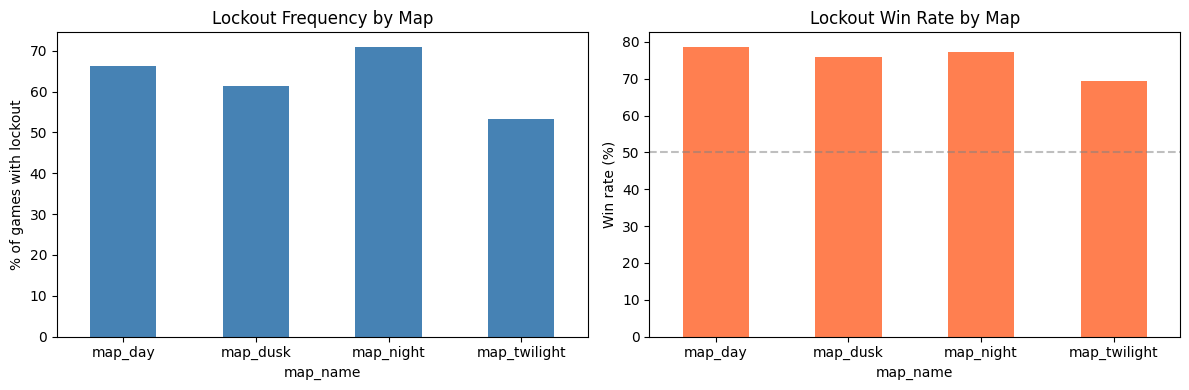

In [4]:
# Lockout by map
map_stats = df.groupby('map_name').agg(
    total=('has_lockout', 'count'),
    lockout_count=('has_lockout', 'sum'),
).assign(lockout_pct=lambda x: x['lockout_count'] / x['total'] * 100)

map_win = lockout_df.groupby('map_name')['lockout_team_wins'].agg(['mean', 'count'])
map_win.columns = ['lockout_win_rate', 'n_lockout']
map_win['lockout_win_rate'] *= 100

map_combined = map_stats.join(map_win)
print(map_combined)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

map_combined['lockout_pct'].plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Lockout Frequency by Map')
axes[0].set_ylabel('% of games with lockout')
axes[0].tick_params(axis='x', rotation=0)

map_combined['lockout_win_rate'].plot.bar(ax=axes[1], color='coral')
axes[1].set_title('Lockout Win Rate by Map')
axes[1].set_ylabel('Win rate (%)')
axes[1].axhline(50, color='gray', linestyle='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [5]:
# Join with ratings
ratings_by_game = pickle.load(open('ratings.pkl', 'rb'))

# Ratings indices: gold_queen=0, blue_queen=1,
# gold_drones=2,4,6,8, blue_drones=3,5,7,9

def get_team_ratings(game_id, team_str):
    """Return (queen_mu, avg_drone_mu) for the given team."""
    r = ratings_by_game.get(game_id)
    if r is None:
        return None, None
    if team_str == 'blue':
        queen_mu = float(r[1])
        drone_mus = [float(r[i]) for i in [3, 5, 7, 9]]
    else:
        queen_mu = float(r[0])
        drone_mus = [float(r[i]) for i in [2, 4, 6, 8]]
    return queen_mu, np.mean(drone_mus)


lockout_ratings = []
for _, row in lockout_df.iterrows():
    lo_team = row['lockout_team']
    victim_team = 'gold' if lo_team == 'blue' else 'blue'
    lo_queen, lo_drone_avg = get_team_ratings(row['game_id'], lo_team)
    vi_queen, vi_drone_avg = get_team_ratings(row['game_id'], victim_team)
    lockout_ratings.append({
        'game_id': row['game_id'],
        'lo_queen_mu': lo_queen,
        'lo_drone_avg_mu': lo_drone_avg,
        'vi_queen_mu': vi_queen,
        'vi_drone_avg_mu': vi_drone_avg,
    })

ratings_df = pd.DataFrame(lockout_ratings)
lo = lockout_df.merge(ratings_df, on='game_id')
lo = lo.dropna(subset=['lo_queen_mu'])
lo['skill_diff'] = (lo['lo_queen_mu'] + lo['lo_drone_avg_mu']) - (lo['vi_queen_mu'] + lo['vi_drone_avg_mu'])
lo['queen_diff'] = lo['lo_queen_mu'] - lo['vi_queen_mu']
print(f'Lockout games with ratings: {len(lo)}')
lo[['lo_queen_mu', 'lo_drone_avg_mu', 'vi_queen_mu', 'vi_drone_avg_mu', 'skill_diff']].describe()

Lockout games with ratings: 12058


,lo_queen_mu,lo_drone_avg_mu,vi_queen_mu,vi_drone_avg_mu,skill_diff
count,12058.000000,12058.000000,12058.000000,12058.000000,12058.000000
mean,2.563297,1.529611,1.878700,1.042280,1.171928
std,5.347314,4.705522,5.184053,4.601715,5.847747
min,-12.132931,-9.871549,-11.838443,-9.794406,-39.864186
25%,-0.384231,-0.942823,-1.233734,-1.326167,-2.520420
50%,2.016981,0.375736,1.292203,-0.066133,1.118740
75%,4.286359,2.137173,3.727053,1.641782,4.709055
max,39.638729,31.448962,40.724133,29.332807,35.712068


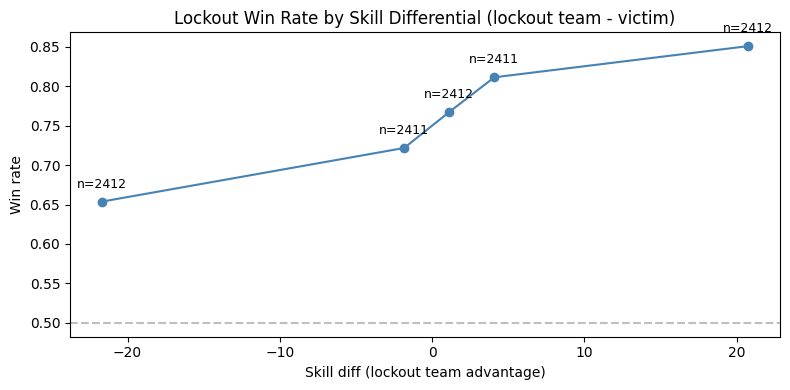


Key question: does lockout override a skill deficit?
Lockout team is lower-skilled: 5022 games, win rate: 69.0%


In [6]:
# Lockout win rate by skill differential
lo['skill_diff_bin'] = pd.qcut(lo['skill_diff'], q=5, duplicates='drop')

skill_win = lo.groupby('skill_diff_bin', observed=True)['lockout_team_wins'].agg(['mean', 'count'])
skill_win.columns = ['win_rate', 'n']

fig, ax = plt.subplots(figsize=(8, 4))
midpoints = [interval.mid for interval in skill_win.index]
ax.plot(midpoints, skill_win['win_rate'], marker='o', color='steelblue')
ax.set_title('Lockout Win Rate by Skill Differential (lockout team - victim)')
ax.set_ylabel('Win rate')
ax.set_xlabel('Skill diff (lockout team advantage)')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
for x, (_, row) in zip(midpoints, skill_win.iterrows()):
    ax.annotate(f'n={row["n"]:.0f}', (x, row['win_rate']), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nKey question: does lockout override a skill deficit?')
behind = lo[lo['skill_diff'] < 0]
print(f'Lockout team is lower-skilled: {len(behind)} games, win rate: {behind["lockout_team_wins"].mean():.1%}')

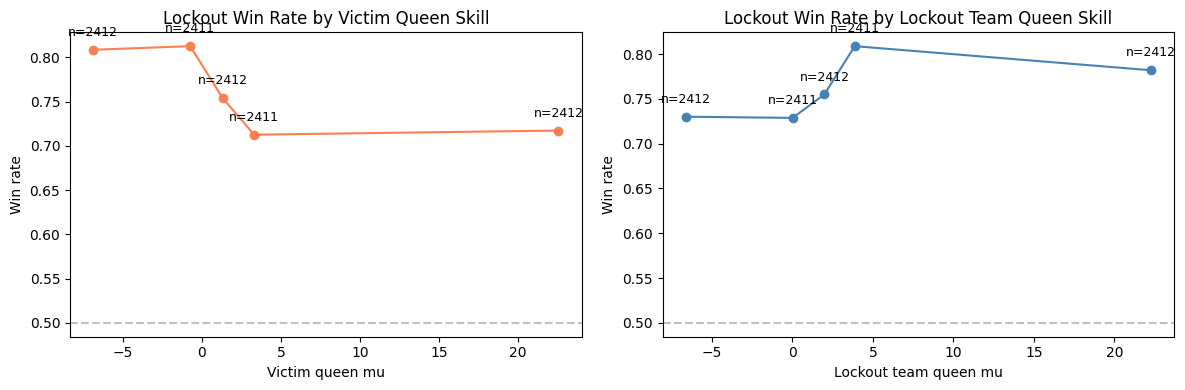

In [7]:
# Lockout win rate by queen skill
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Victim queen skill
lo['vi_queen_bin'] = pd.qcut(lo['vi_queen_mu'], q=5, duplicates='drop')
vq = lo.groupby('vi_queen_bin', observed=True)['lockout_team_wins'].agg(['mean', 'count'])
midpoints_vq = [interval.mid for interval in vq.index]
axes[0].plot(midpoints_vq, vq['mean'], marker='o', color='coral')
axes[0].set_title('Lockout Win Rate by Victim Queen Skill')
axes[0].set_ylabel('Win rate')
axes[0].set_xlabel('Victim queen mu')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
for x, (_, row) in zip(midpoints_vq, vq.iterrows()):
    axes[0].annotate(f'n={row["count"]:.0f}', (x, row['mean']), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9)

# Lockout team queen skill
lo['lo_queen_bin'] = pd.qcut(lo['lo_queen_mu'], q=5, duplicates='drop')
lq = lo.groupby('lo_queen_bin', observed=True)['lockout_team_wins'].agg(['mean', 'count'])
midpoints_lq = [interval.mid for interval in lq.index]
axes[1].plot(midpoints_lq, lq['mean'], marker='o', color='steelblue')
axes[1].set_title('Lockout Win Rate by Lockout Team Queen Skill')
axes[1].set_ylabel('Win rate')
axes[1].set_xlabel('Lockout team queen mu')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
for x, (_, row) in zip(midpoints_lq, lq.iterrows()):
    axes[1].annotate(f'n={row["count"]:.0f}', (x, row['mean']), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Even-skill games (|skill_diff| < 5.8): 8524


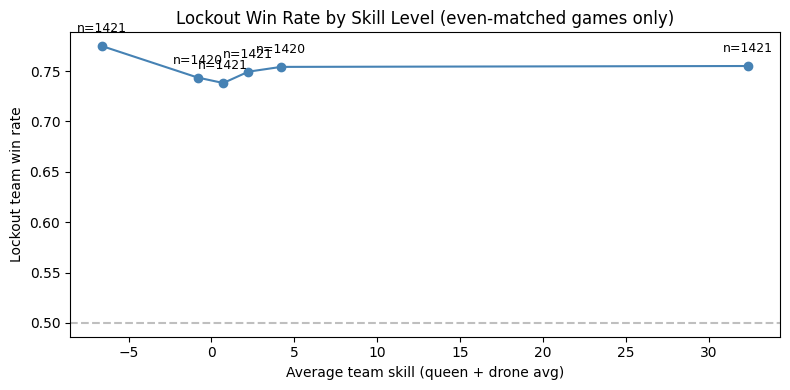


Lowest skill bin win rate: 77.5%
Highest skill bin win rate: 75.5%


In [8]:
# Lockout punitiveness by skill level for evenly-matched games
# "Even" = skill_diff within +/- 1 standard deviation of the median (~0)
skill_diff_std = lo['skill_diff'].std()
even = lo[lo['skill_diff'].abs() < skill_diff_std].copy()
print(f'Even-skill games (|skill_diff| < {skill_diff_std:.1f}): {len(even)}')

# Average team skill = mean of lockout + victim team ratings
even['avg_skill'] = (lo['lo_queen_mu'] + lo['lo_drone_avg_mu'] +
                     lo['vi_queen_mu'] + lo['vi_drone_avg_mu']) / 2
even['skill_bin'] = pd.qcut(even['avg_skill'], q=6, duplicates='drop')

skill_level = even.groupby('skill_bin', observed=True)['lockout_team_wins'].agg(['mean', 'count'])
midpoints = [interval.mid for interval in skill_level.index]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(midpoints, skill_level['mean'], marker='o', color='steelblue')
ax.set_title('Lockout Win Rate by Skill Level (even-matched games only)')
ax.set_ylabel('Lockout team win rate')
ax.set_xlabel('Average team skill (queen + drone avg)')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
for x, (_, row) in zip(midpoints, skill_level.iterrows()):
    ax.annotate(f'n={row["count"]:.0f}', (x, row['mean']), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f'\nLowest skill bin win rate: {skill_level["mean"].iloc[0]:.1%}')
print(f'Highest skill bin win rate: {skill_level["mean"].iloc[-1]:.1%}')

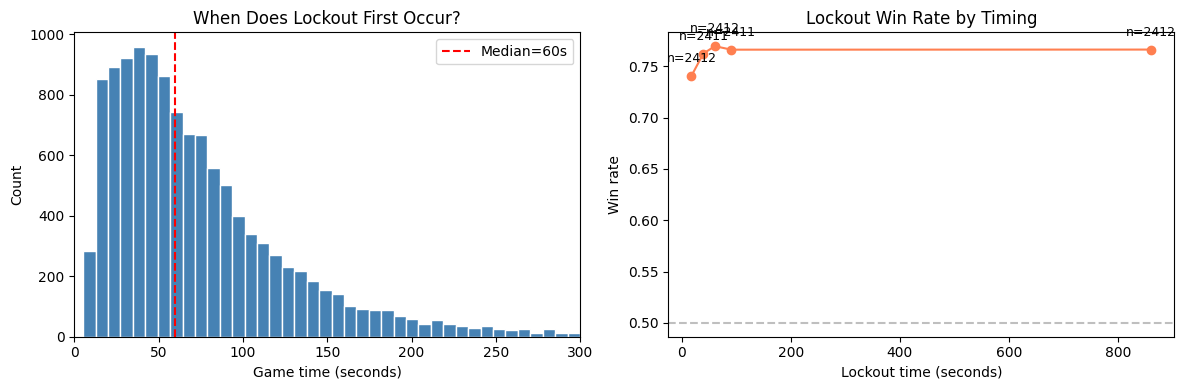

Median lockout time: 60s
Lockouts beyond 300s: 93
Early lockout win rate: 75.5% (n=6029)
Late lockout win rate: 76.7% (n=6029)


In [9]:
# Temporal analysis: when does lockout happen and how decisive is early vs late?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of lockout timestamps (clamp to 0-300s)
lockout_ts = lockout_df['lockout_timestamp'].dropna()
lockout_ts_clamped = lockout_ts[lockout_ts <= 300]
axes[0].hist(lockout_ts_clamped, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('When Does Lockout First Occur?')
axes[0].set_xlabel('Game time (seconds)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 300)
axes[0].axvline(lockout_ts.median(), color='red', linestyle='--', label=f'Median={lockout_ts.median():.0f}s')
axes[0].legend()

# Win rate by lockout time bin (line graph)
lo_time = lockout_df.copy()
lo_time['time_bin'] = pd.qcut(lo_time['lockout_timestamp'], q=5, duplicates='drop')
time_win = lo_time.groupby('time_bin', observed=True)['lockout_team_wins'].agg(['mean', 'count'])
midpoints_t = [interval.mid for interval in time_win.index]
axes[1].plot(midpoints_t, time_win['mean'], marker='o', color='coral')
axes[1].set_title('Lockout Win Rate by Timing')
axes[1].set_ylabel('Win rate')
axes[1].set_xlabel('Lockout time (seconds)')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
for x, (_, row) in zip(midpoints_t, time_win.iterrows()):
    axes[1].annotate(f'n={row["count"]:.0f}', (x, row['mean']), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Median lockout time: {lockout_ts.median():.0f}s')
print(f'Lockouts beyond 300s: {(lockout_ts > 300).sum()}')
early = lockout_df[lockout_df['lockout_timestamp'] < lockout_ts.median()]
late = lockout_df[lockout_df['lockout_timestamp'] >= lockout_ts.median()]
print(f'Early lockout win rate: {early["lockout_team_wins"].mean():.1%} (n={len(early)})')
print(f'Late lockout win rate: {late["lockout_team_wins"].mean():.1%} (n={len(late)})')

In [10]:
# Tournament analysis
game_meta_df = pd.read_csv('unfiltered_partitioned/game.csv')
game_meta_df = game_meta_df[['id', 'tournament_match_id']].rename(columns={'id': 'game_id'})
game_meta_df['is_tournament'] = game_meta_df['tournament_match_id'].notna()

df2 = df.merge(game_meta_df, on='game_id', how='left')
df2['is_tournament'] = df2['is_tournament'].fillna(False)

# Load tournament clustering for stage info
with open('late_tournament_games/tournament_clustering.json') as f:
    tourney_data = json.load(f)
match_to_tournament = tourney_data['match_to_tournament']
tournaments = tourney_data['tournaments']

# Compare lockout frequency: tournament vs casual
for label, subset in [('Tournament', df2[df2['is_tournament']]),
                       ('Casual', df2[~df2['is_tournament']])]:
    n = len(subset)
    n_lockout = subset['has_lockout'].sum()
    pct = n_lockout / n * 100 if n > 0 else 0
    lockout_sub = subset[subset['has_lockout']]
    # Recompute lockout_team_wins for this subset
    if len(lockout_sub) > 0:
        wins = (
            ((lockout_sub['lockout_team'] == 'blue') & (lockout_sub['blue_wins'] == 1)) |
            ((lockout_sub['lockout_team'] == 'gold') & (lockout_sub['blue_wins'] == 0))
        ).mean() * 100
    else:
        wins = float('nan')
    print(f'{label}: {n} games, {n_lockout} lockouts ({pct:.1f}%), lockout win rate: {wins:.1f}%')

Tournament: 10464 games, 6987 lockouts (66.8%), lockout win rate: 78.3%
Casual: 8442 games, 5071 lockouts (60.1%), lockout win rate: 73.0%
